In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")

In [ ]:
# loading train data (single file)
path = "../data/raw/train_FD001.txt"

df = pd.read_csv(path, sep=" ", header=None)
df = df.dropna(axis=1)

df.head()

,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,25
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [ ]:
# assigning column names
cols = (
    ["engine_id", "cycle"] +
    [f"op_setting_{i}" for i in range(1,4)] +
    [f"sensor_{i}" for i in range(1,22)]
)

df.columns = cols

df.head()

,engine_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [ ]:
# dataset info

print("Dataset shape:", df.shape)
print("Number of engines:", df.engine_id.nunique())

df.describe().T.head()

Dataset shape: (20631, 26)
Number of engines: 100


,count,mean,std,min,25%,50%,75%,max
engine_id,20631.0,51.506568,29.227633,1.0000,26.0000,52.0,77.0000,100.0000
cycle,20631.0,108.807862,68.880990,1.0000,52.0000,104.0,156.0000,362.0000
op_setting_1,20631.0,-0.000009,0.002187,-0.0087,-0.0015,0.0,0.0015,0.0087
op_setting_2,20631.0,0.000002,0.000293,-0.0006,-0.0002,0.0,0.0003,0.0006
op_setting_3,20631.0,100.000000,0.000000,100.0000,100.0000,100.0,100.0000,100.0000


In [6]:
# RUL = C{failure}-C{current}

max_cycle = df.groupby("engine_id")["cycle"].max()

df["max_cycle"] = df["engine_id"].map(max_cycle)

df["RUL"] = df["max_cycle"] - df["cycle"]

df.head()

,engine_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,max_cycle,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,192,191
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,192,190
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,192,189
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,192,188
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,192,187


In [7]:
# clipping RUL to prevent large RUL (when the machine is sorta new)
df["RUL"] = df["RUL"].clip(upper=125)

df["RUL"].describe()

count    20631.000000
mean        86.829286
std         41.673699
min          0.000000
25%         51.000000
50%        103.000000
75%        125.000000
max        125.000000
Name: RUL, dtype: float64

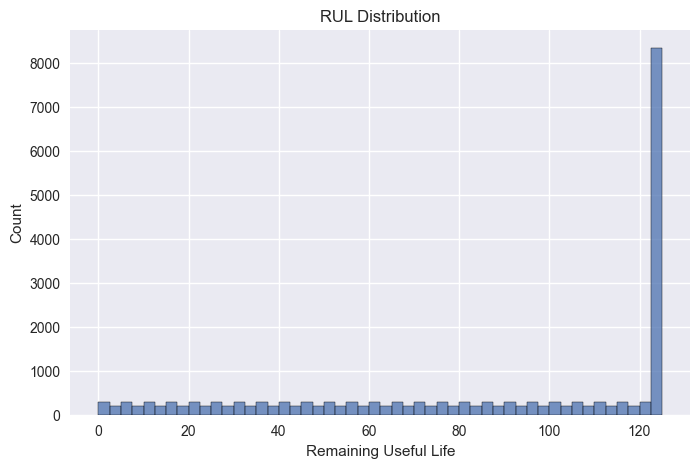

In [9]:
# RUL distribution curve

plt.figure(figsize=(8,5))
sns.histplot(df["RUL"], bins=50)
plt.title("RUL Distribution")
plt.xlabel("Remaining Useful Life")
plt.show()

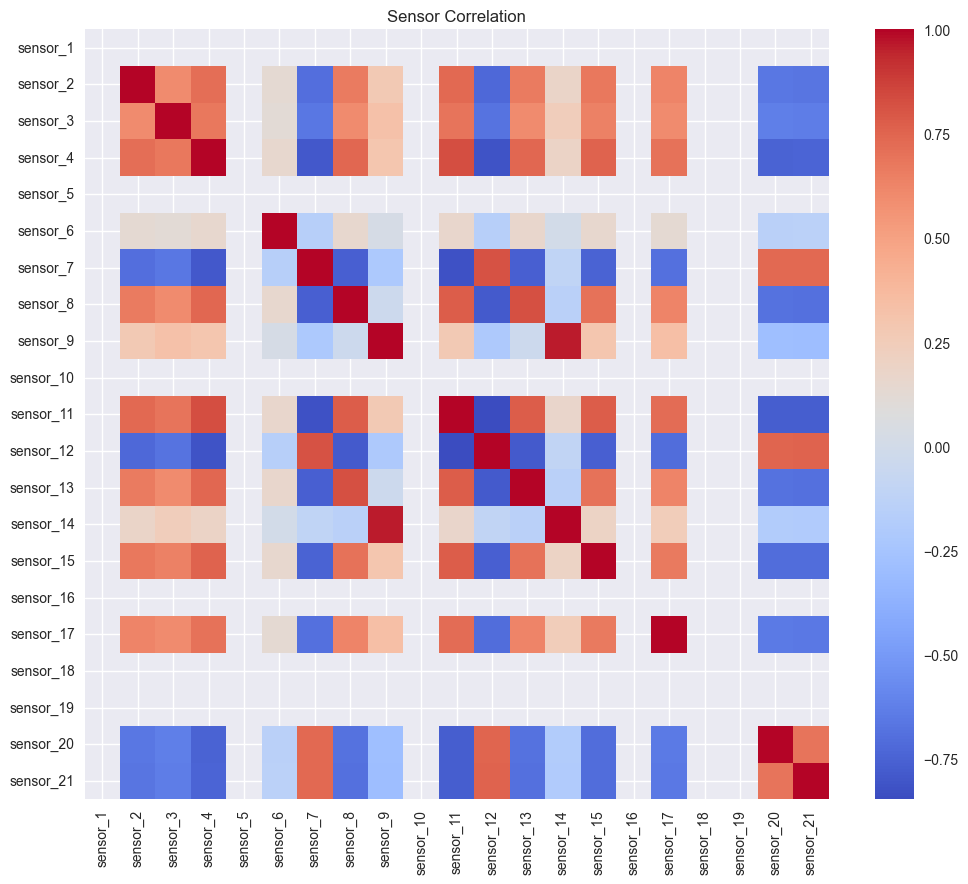

In [12]:
# sensor coo-relation
sensor_cols = [col for col in df.columns if "sensor" in col]

corr = df[sensor_cols].corr()

plt.figure(figsize=(12,10))
sns.heatmap(corr, cmap="coolwarm")
plt.title("Sensor Correlation")
plt.show()

In [11]:
df = df.drop(columns=["max_cycle"])

df.to_csv("../data/processed/train_clean.csv", index=False)

print("Saved cleaned dataset.")

Saved cleaned dataset.
